# Fairness Analysis

Logistic regression trained on the 130-US Hospitals Diabetes Dataset (1999–2008) to predict 30-day readmission. We assess fairness across gender, race, and insurance (payer code) groups, using False Negative Rate (FNR) as our primary fairness metric.

<br><br>

## 0. Setup

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import shap
import pandas as pd
from sklearn.model_selection import train_test_split

In [20]:
# Load data
diabetes = pd.read_csv("data/diabetes_processed.csv")
ids = pd.read_csv("data/diabetes/IDS_mapping.csv")

In [21]:
target_name = 'readmitted'

X = diabetes[[c for c in diabetes if c != target_name]].copy()
y = diabetes[target_name].copy()

# Protected attribute for fairness analysis
group = diabetes["gender"].astype(int)

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X,
    y,
    group,
    test_size=0.2,
    random_state=0,
    stratify=y
)

<br><br>

## 1. Baseline Model

Full logistic regression trained on all available features including sensitive attributes (race, gender, payer code). Uses `class_weight='balanced'` to compensate for the ~9:1 class imbalance.

In [22]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 55989 entries, 62192 to 5861
Data columns (total 85 columns):
 #   Column                                          Non-Null Count  Dtype
---  ------                                          --------------  -----
 0   gender                                          55989 non-null  int64
 1   age                                             55989 non-null  int64
 2   time_in_hospital                                55989 non-null  int64
 3   num_lab_procedures                              55989 non-null  int64
 4   num_procedures                                  55989 non-null  int64
 5   num_medications                                 55989 non-null  int64
 6   number_diagnoses                                55989 non-null  int64
 7   metformin                                       55989 non-null  int64
 8   repaglinide                                     55989 non-null  int64
 9   nateglinide                                     55989 non-null  int64
 10 

In [23]:
def print_classification_results(y_test, y_pred):
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

In [24]:
def get_log_reg_pipeline(
    seed: int = 70766,
    max_iter: int = 5000,
    penalty: str = 'l2',
    C: float = 0.8497534359086438,
    tol: float = 1e-4,
    solver: str = 'saga'
):
    scaler = StandardScaler() # Standard scale for log reg
    model = LogisticRegression(
        class_weight='balanced',
        penalty = penalty,
        C = C,
        random_state = seed,
        max_iter = max_iter,
        tol = tol,
        solver = solver
    )
    pipeline = Pipeline([('scaler', scaler), ('classifier', model)])
    return pipeline

In [25]:
# Get pipeline and fit to training data
log_reg = get_log_reg_pipeline()
log_reg.fit(X_train, y_train)

# Predict on test set
log_reg_y_pred = log_reg.predict(X_test)

# Evaluate
print_classification_results(y_test, log_reg_y_pred)

/Users/sanderengelthilo/Documents/ITU/AFAE/exam/afae_exam_project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 0.6274
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76     12741
           1       0.13      0.54      0.21      1257

    accuracy                           0.63     13998
   macro avg       0.53      0.59      0.48     13998
weighted avg       0.86      0.63      0.71     13998



In [26]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, log_reg_y_pred))

[[8102 4639]
 [ 577  680]]


<br><br>

## 2. Fairness Analysis

### 2.1 Helper Functions

In [27]:
def get_scores_test(model, X_test):
    return model.predict_proba(X_test)[:, 1]

def make_selection(scores_test, thresholds: tuple = (.5, .5)):
    # Apply group-specific thresholds
    selections = np.zeros_like(scores_test)
    selections[group_test == 0] = (scores_test[group_test == 0] >= thresholds[0]).astype(int)
    selections[group_test == 1] = (scores_test[group_test == 1] >= thresholds[1]).astype(int)
    return selections

# Define function to evaluate fairness
def evaluate_fairness(S, T, G):
    df = pd.DataFrame({'S': S, 'T': T, 'G': G})

    results = {}
    for g in [0, 1]: # Male, Female
        subset = df[df['G'] == g]

        # Statistical/demographic parity P(S=1|G)
        results[f'G={g}_Selection_Rate'] = subset['S'].mean()

        # Equalized Odds P(S=1|G, T)
        results[f'G={g}_TPR'] = subset[subset['T'] == 1]['S'].mean()
        results[f'G={g}_FPR'] = subset[subset['T'] == 0]['S'].mean()

        # Equalized Outcome P(T=1|G, S)
        results[f'G={g}_Prec'] = subset[subset['S'] == 1]['T'].mean()
        results[f'G={g}_NPV'] = subset[subset['S'] == 0]['T'].mean()

    return results

def print_fairness_overiew(fairness_metrics: dict, epsilon: float = 1e-3):
    # Statistical parity
    print('Statistical Parity:')
    g1_selection_rate = fairness_metrics['G=0_Selection_Rate']
    g2_selection_rate = fairness_metrics['G=1_Selection_Rate']
    print(f'Group 0 Selection Rate P(S=1|G=0): {g1_selection_rate:.4f}')
    print(f'Group 1 Selection Rate P(S=1|G=1): {g2_selection_rate:.4f}')
    if abs(g1_selection_rate - g2_selection_rate) < epsilon:
        print('Statistical parity (approximately) achieved.')
    else:
        print('Statistical parity not achieved.')
    print('')

    # Equalized Odds
    print('Equalized Odds:')
    g0_tpr = fairness_metrics['G=0_TPR']
    g1_tpr = fairness_metrics['G=1_TPR']
    g0_fpr = fairness_metrics['G=0_FPR']
    g1_fpr = fairness_metrics['G=1_FPR']

    print(f'Group 0 True Positive Rate P(S=1|G=0,T=1): {g0_tpr:.4f}')
    print(f'Group 1 True Positive Rate P(S=1|G=1,T=1): {g1_tpr:.4f}')

    print(f'Group 0 False Positive Rate P(S=1|G=0,T=0): {g0_fpr:.4f}')
    print(f'Group 1 False Positive Rate P(S=1|G=1,T=0): {g1_fpr:.4f}')
    if abs(g0_tpr - g1_tpr) < epsilon and abs(g0_fpr - g1_fpr) < epsilon:
        print('Equalized odds (approximately) achieved.')
    else:
        print('Equalized odds not achieved.')

def plot_fairness_metrics(fairness_metrics: dict, scores_test, roc_cross: tuple = None):
    _, axes = plt.subplots(1, 2, figsize = (12, 6))

    # ROC curve
    for g, label in zip([0, 1], ['Group 0', 'Group 1']):
        idx = group_test == g
        fpr, tpr, _ = roc_curve(y_test[idx], scores_test[idx])
        axes[0].plot(fpr, tpr, label=label)

    if roc_cross is not None:
        axes[0].scatter([roc_cross[0]], [roc_cross[1]], marker = 'x', color = 'red', s = 100)

    axes[0].grid(True, linestyle = '--')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve by Group')
    axes[0].legend()

    # Bar plot
    groups = ['Group 0', 'Group 1']
    selection_rates = [fairness_metrics['G=0_Selection_Rate'], fairness_metrics['G=1_Selection_Rate']]
    axes[1].bar(groups, selection_rates)
    axes[1].set_ylabel('Selection Rate')
    axes[1].set_title('Selection Rate by Group')
    plt.show()

In [ ]:
def evaluate_fairness_by_group(S, T, G):
    df = pd.DataFrame({"S": S, "T": T, "G": G})

    results = {}

    for g in df["G"].unique():
        subset = df[df["G"] == g]

        results[f"G={g}_Selection_Rate"] = subset["S"].mean()
        results[f"G={g}_TPR"] = subset[subset["T"] == 1]["S"].mean()
        results[f"G={g}_FPR"] = subset[subset["T"] == 0]["S"].mean()
        results[f"G={g}_Prec"] = subset[subset["S"] == 1]["T"].mean()
        results[f"G={g}_NPV"] = subset[subset["S"] == 0]["T"].mean()

    return results

In [33]:
def plot_fairness_by_group(fairness_metrics, scores_test, group_values, title="Group"):
    _, axes = plt.subplots(1, 2, figsize=(14, 6))

    for g in group_values.unique():
        idx = group_values == g

        # Only plot ROC if the group has both classes
        if y_test[idx].nunique() == 2:
            fpr, tpr, _ = roc_curve(y_test[idx], scores_test[idx])
            axes[0].plot(fpr, tpr, label=str(g))

    axes[0].grid(True, linestyle="--")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC Curve by {title}")
    axes[0].legend()

    groups = list(group_values.unique())
    selection_rates = [
        fairness_metrics[f"G={g}_Selection_Rate"]
        for g in groups
    ]

    axes[1].bar(groups, selection_rates)
    axes[1].set_ylabel("Selection Rate")
    axes[1].set_title(f"Selection Rate by {title}")
    axes[1].tick_params(axis="x", rotation=45)

    plt.show()

### 2.2 Fairness by Gender

Statistical Parity:
Group 0 Selection Rate P(S=1|G=0): 0.3808
Group 1 Selection Rate P(S=1|G=1): 0.3791
Statistical parity not achieved.

Equalized Odds:
Group 0 True Positive Rate P(S=1|G=0,T=1): 0.5253
Group 1 True Positive Rate P(S=1|G=1,T=1): 0.5590
Group 0 False Positive Rate P(S=1|G=0,T=0): 0.3664
Group 1 False Positive Rate P(S=1|G=1,T=0): 0.3615
Equalized odds not achieved.


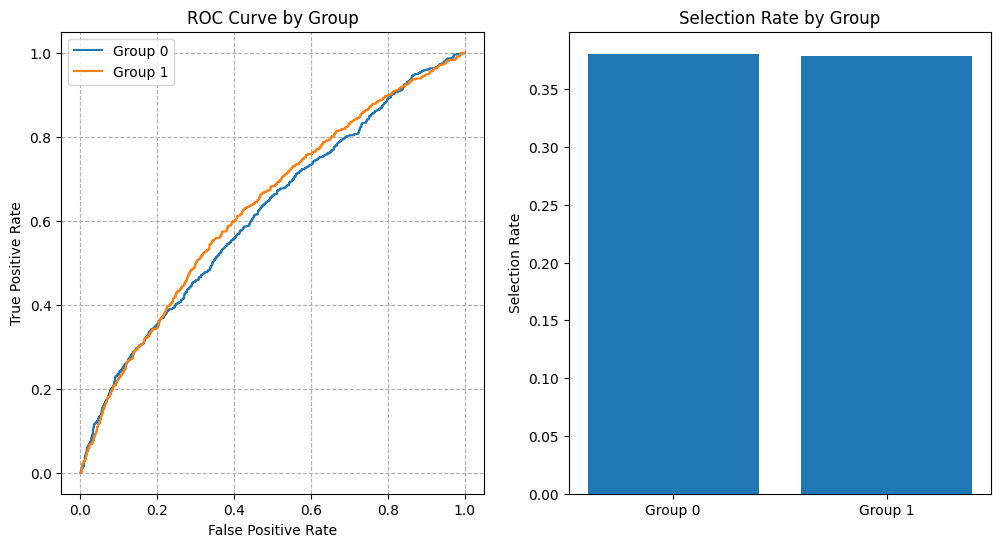

In [28]:
# Get test scores and make selections
log_reg_scores_test = get_scores_test(log_reg, X_test)
log_reg_selections = make_selection(log_reg_scores_test)
log_reg_fairness_metrics = evaluate_fairness(log_reg_selections, y_test, group_test)
print_fairness_overiew(log_reg_fairness_metrics)
plot_fairness_metrics(log_reg_fairness_metrics, log_reg_scores_test)

### 2.3 Fairness by Race

In [30]:
race_columns = [
    "race_Asian",
    "race_AfricanAmerican",
    "race_Hispanic",
    "race_Other"
]

def get_race(row):
    if row["race_Asian"] == 1:
        return "Asian"
    elif row["race_AfricanAmerican"] == 1:
        return "AfricanAmerican"
    elif row["race_Hispanic"] == 1:
        return "Hispanic"
    elif row["race_Other"] == 1:
        return "Other"
    else:
        return "Caucasian"

race_test = X_test.apply(get_race, axis=1)

### 2.4 Fairness by Payer Code (Social Proxy)

Payer code (insurance type) may act as a social proxy for race and socioeconomic status. We test whether the model shows disparate error rates across insurance groups.

In [ ]:
# Reconstruct payer code from one-hot encoded columns
payer_columns = [col for col in X_test.columns if col.startswith("payer_code_")]

def get_payer(row):
    for col in payer_columns:
        if row[col] == 1:
            return col.replace("payer_code_", "")
    return "Unknown"

payer_test = X_test.apply(get_payer, axis=1)

# Compute predictions and payer fairness metrics
log_reg_scores_test = get_scores_test(log_reg, X_test)
log_reg_selections = (log_reg_scores_test >= 0.5).astype(int)

payer_fairness_metrics = evaluate_fairness_by_group(log_reg_selections, y_test, payer_test)
payer_fairness_metrics

{'G=MC_Selection_Rate': np.float64(0.4553201850499148),
 'G=MC_TPR': np.float64(0.5778364116094987),
 'G=MC_FPR': np.float64(0.4428648068669528),
 'G=MC_Prec': np.float64(0.11711229946524064),
 'G=MC_NPV': np.float64(0.07152436298614215),
 'G=PO_Selection_Rate': np.float64(0.06172839506172839),
 'G=PO_TPR': np.float64(0.2),
 'G=PO_FPR': np.float64(0.05263157894736842),
 'G=PO_Prec': np.float64(0.2),
 'G=PO_NPV': np.float64(0.05263157894736842),
 'G=Unknown_Selection_Rate': np.float64(0.4056618209640398),
 'G=Unknown_TPR': np.float64(0.5848142164781907),
 'G=Unknown_FPR': np.float64(0.3869168356997972),
 'G=Unknown_Prec': np.float64(0.13655224443606187),
 'G=Unknown_NPV': np.float64(0.06616889804325438),
 'G=MD_Selection_Rate': np.float64(0.29850746268656714),
 'G=MD_TPR': np.float64(0.3684210526315789),
 'G=MD_FPR': np.float64(0.2923433874709977),
 'G=MD_Prec': np.float64(0.1),
 'G=MD_NPV': np.float64(0.0729483282674772),
 'G=SP_Selection_Rate': np.float64(0.24671532846715327),
 'G=SP_

In [32]:
payer_results = []

for payer in payer_test.unique():
    payer_results.append({
        "Payer Code": payer,
        "N": (payer_test == payer).sum(),
        "Selection Rate": payer_fairness_metrics[f"G={payer}_Selection_Rate"],
        "TPR": payer_fairness_metrics[f"G={payer}_TPR"],
        "FPR": payer_fairness_metrics[f"G={payer}_FPR"],
        "Precision": payer_fairness_metrics[f"G={payer}_Prec"],
        "NPV": payer_fairness_metrics[f"G={payer}_NPV"]
    })

payer_fairness_df = pd.DataFrame(payer_results)
payer_fairness_df.sort_values("N", ascending=False)



,Payer Code,N,Selection Rate,TPR,FPR,Precision,NPV
2,Unknown,6535,0.405662,0.584814,0.386917,0.136552,0.066169
0,MC,4107,0.455320,0.577836,0.442865,0.117112,0.071524
5,HM,823,0.191981,0.327869,0.181102,0.126582,0.061654
4,SP,685,0.246715,0.415094,0.232595,0.130178,0.060078
3,MD,469,0.298507,0.368421,0.292343,0.100000,0.072948
8,CP,384,0.153646,0.296296,0.142857,0.135593,0.058462
10,UN,378,0.269841,0.464286,0.254286,0.127451,0.054348
7,CM,250,0.368000,0.631579,0.346320,0.130435,0.044304
9,OG,156,0.160256,0.133333,0.163121,0.080000,0.099237
1,PO,81,0.061728,0.200000,0.052632,0.200000,0.052632


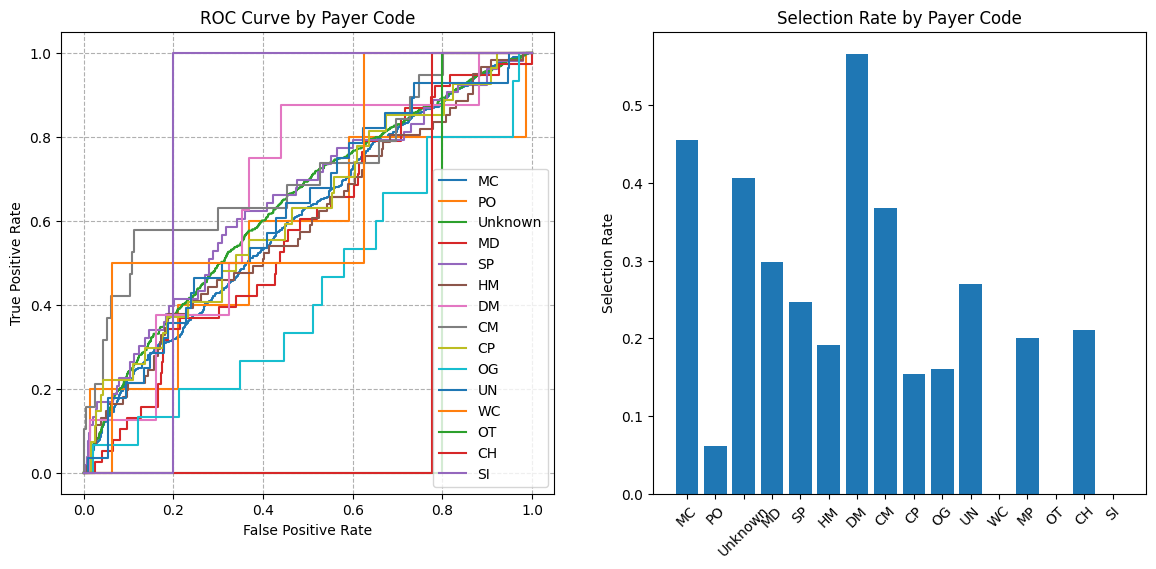

In [34]:
plot_fairness_by_group(
    payer_fairness_metrics,
    log_reg_scores_test,
    payer_test,
    title="Payer Code"
)

<br><br>

## 3. Explainability — SHAP

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to individual predictions. We examine both global patterns and the specific role of sensitive demographic features.

### 3.1 Global Explanations

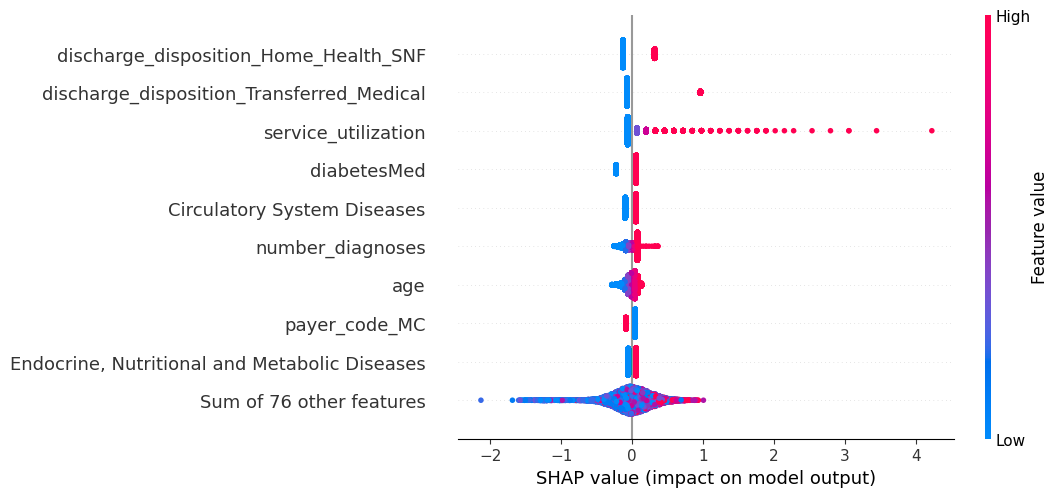

In [35]:
scaler = log_reg.named_steps["scaler"]
clf_lr = log_reg.named_steps["classifier"]

# Scaleing train and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)


explainer = shap.Explainer(clf_lr, X_train_scaled_df)
shap_values = explainer(X_test_scaled_df)
shap.plots.beeswarm(shap_values, max_display=10)

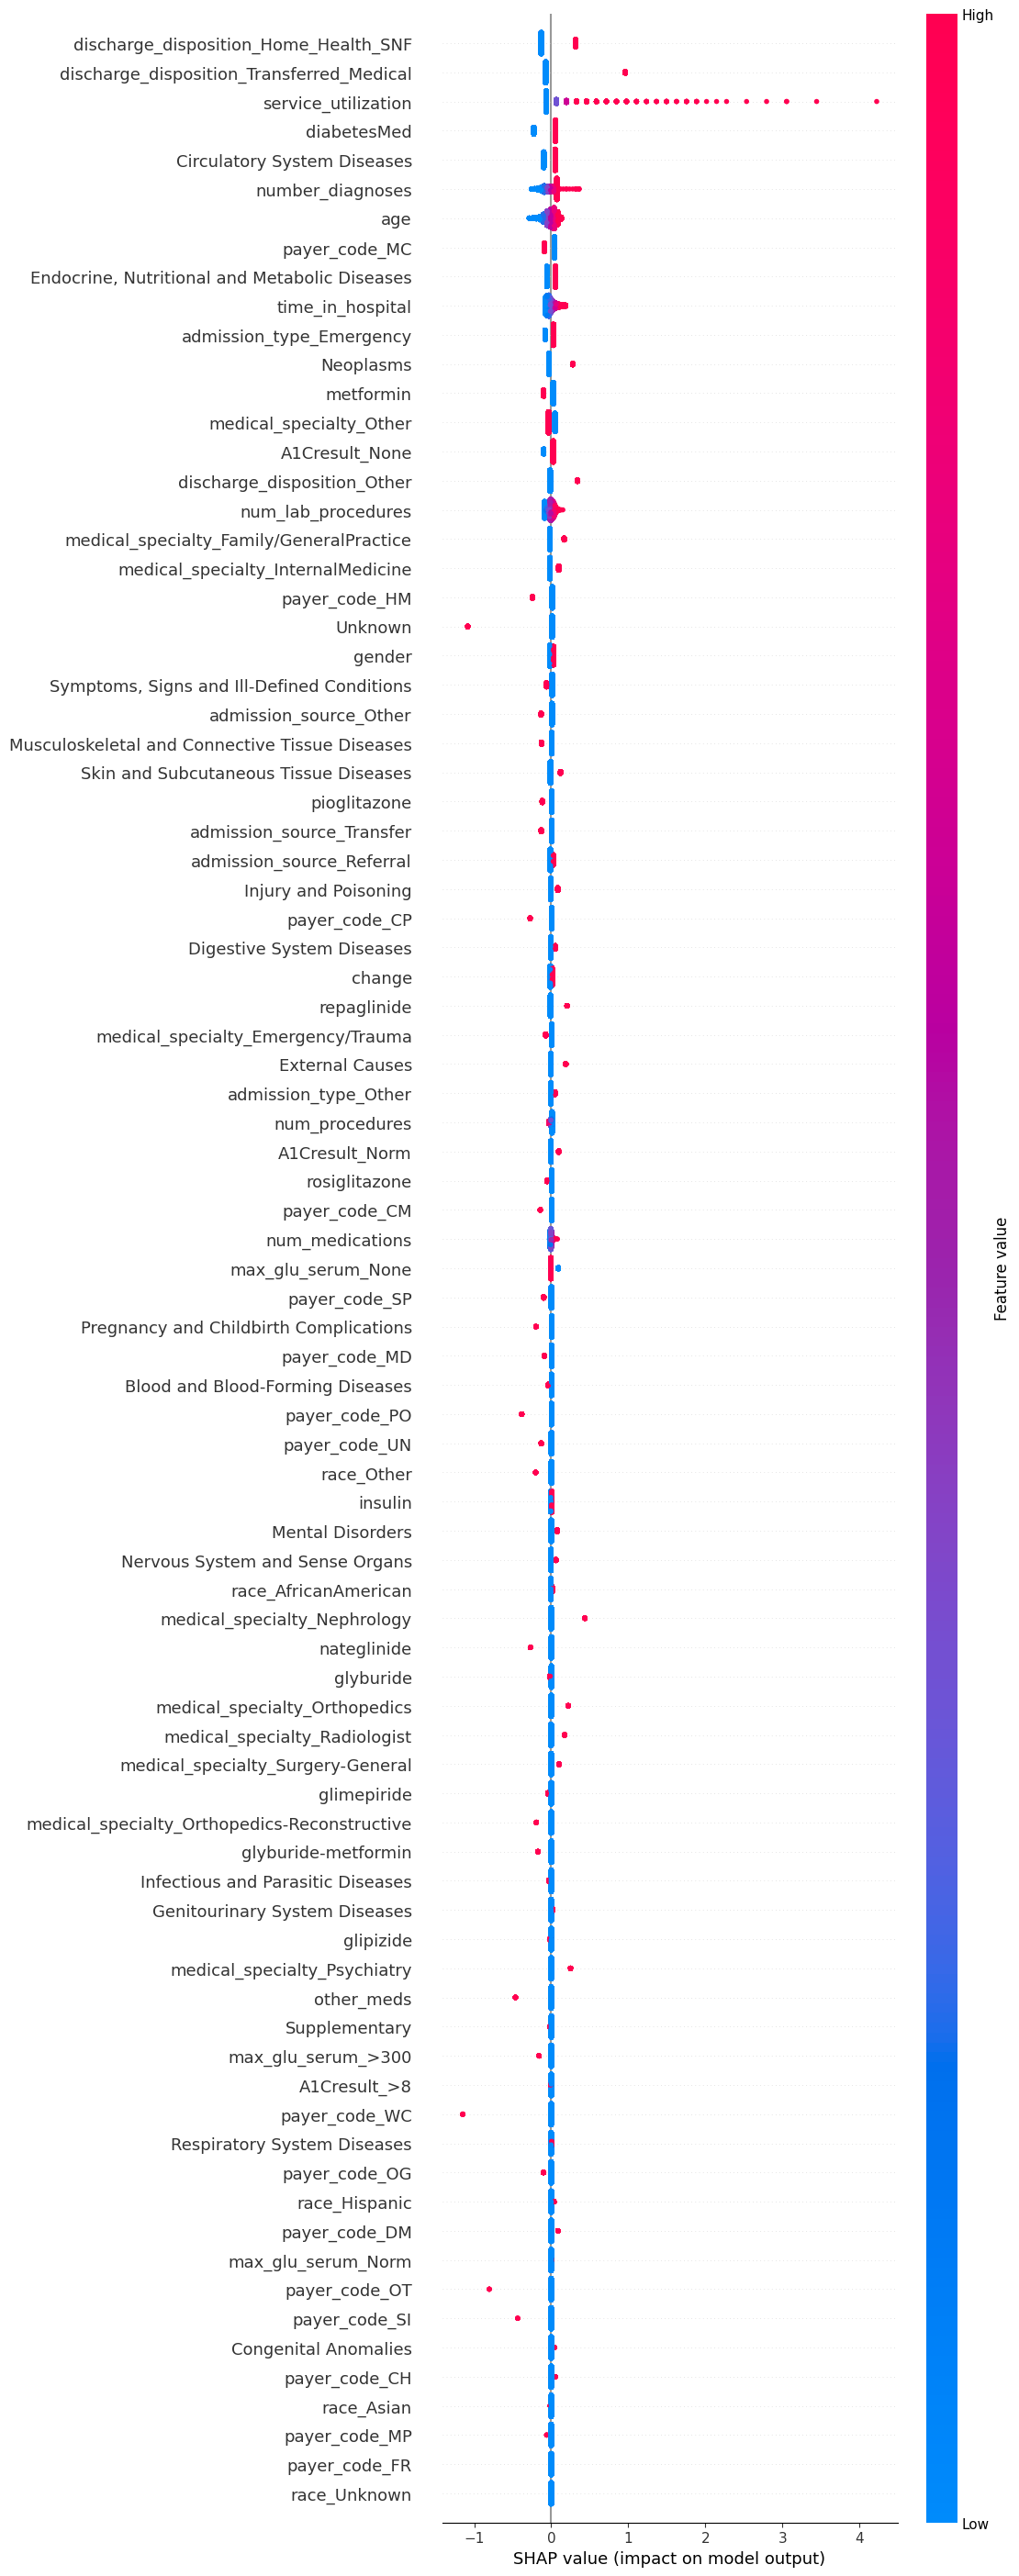

In [36]:
shap.plots.beeswarm(shap_values, max_display=len(X_train.columns))

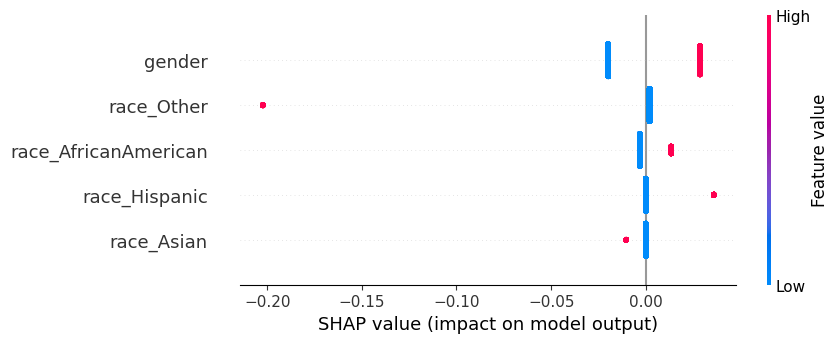

In [38]:
sensitive_features = [
    "gender",
    "race_Asian",
    "race_AfricanAmerican",
    "race_Hispanic",
    "race_Other"
]

# Get column indices of sensitive features
sensitive_idx = [
    list(X_train.columns).index(col)
    for col in sensitive_features
]

# Creating SHAP values for only sensitive features
sensitive_shap = shap_values[:, sensitive_idx]
shap.plots.beeswarm(sensitive_shap)

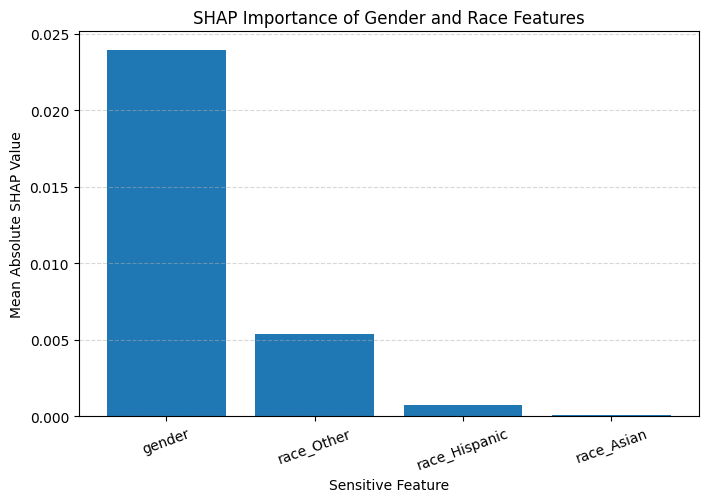

In [ ]:
sensitive_features = [
    "gender",
    "race_Asian",
    "race_AfricanAmerican",
    "race_Hispanic",
    "race_Other"
]

# Computing mean absolute SHAP values
mean_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "mean_abs_shap": mean_shap
})

# Keeping only sensitive features
protected_importance = importance_df[
    importance_df["feature"].isin(sensitive_features)
].sort_values("mean_abs_shap", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(
    protected_importance["feature"],
    protected_importance["mean_abs_shap"]
)
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Sensitive Feature")
plt.title("SHAP Importance of Gender and Race Features")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### 3.2 Local Explanations

Bar plots showing feature contributions for a single patient prediction.

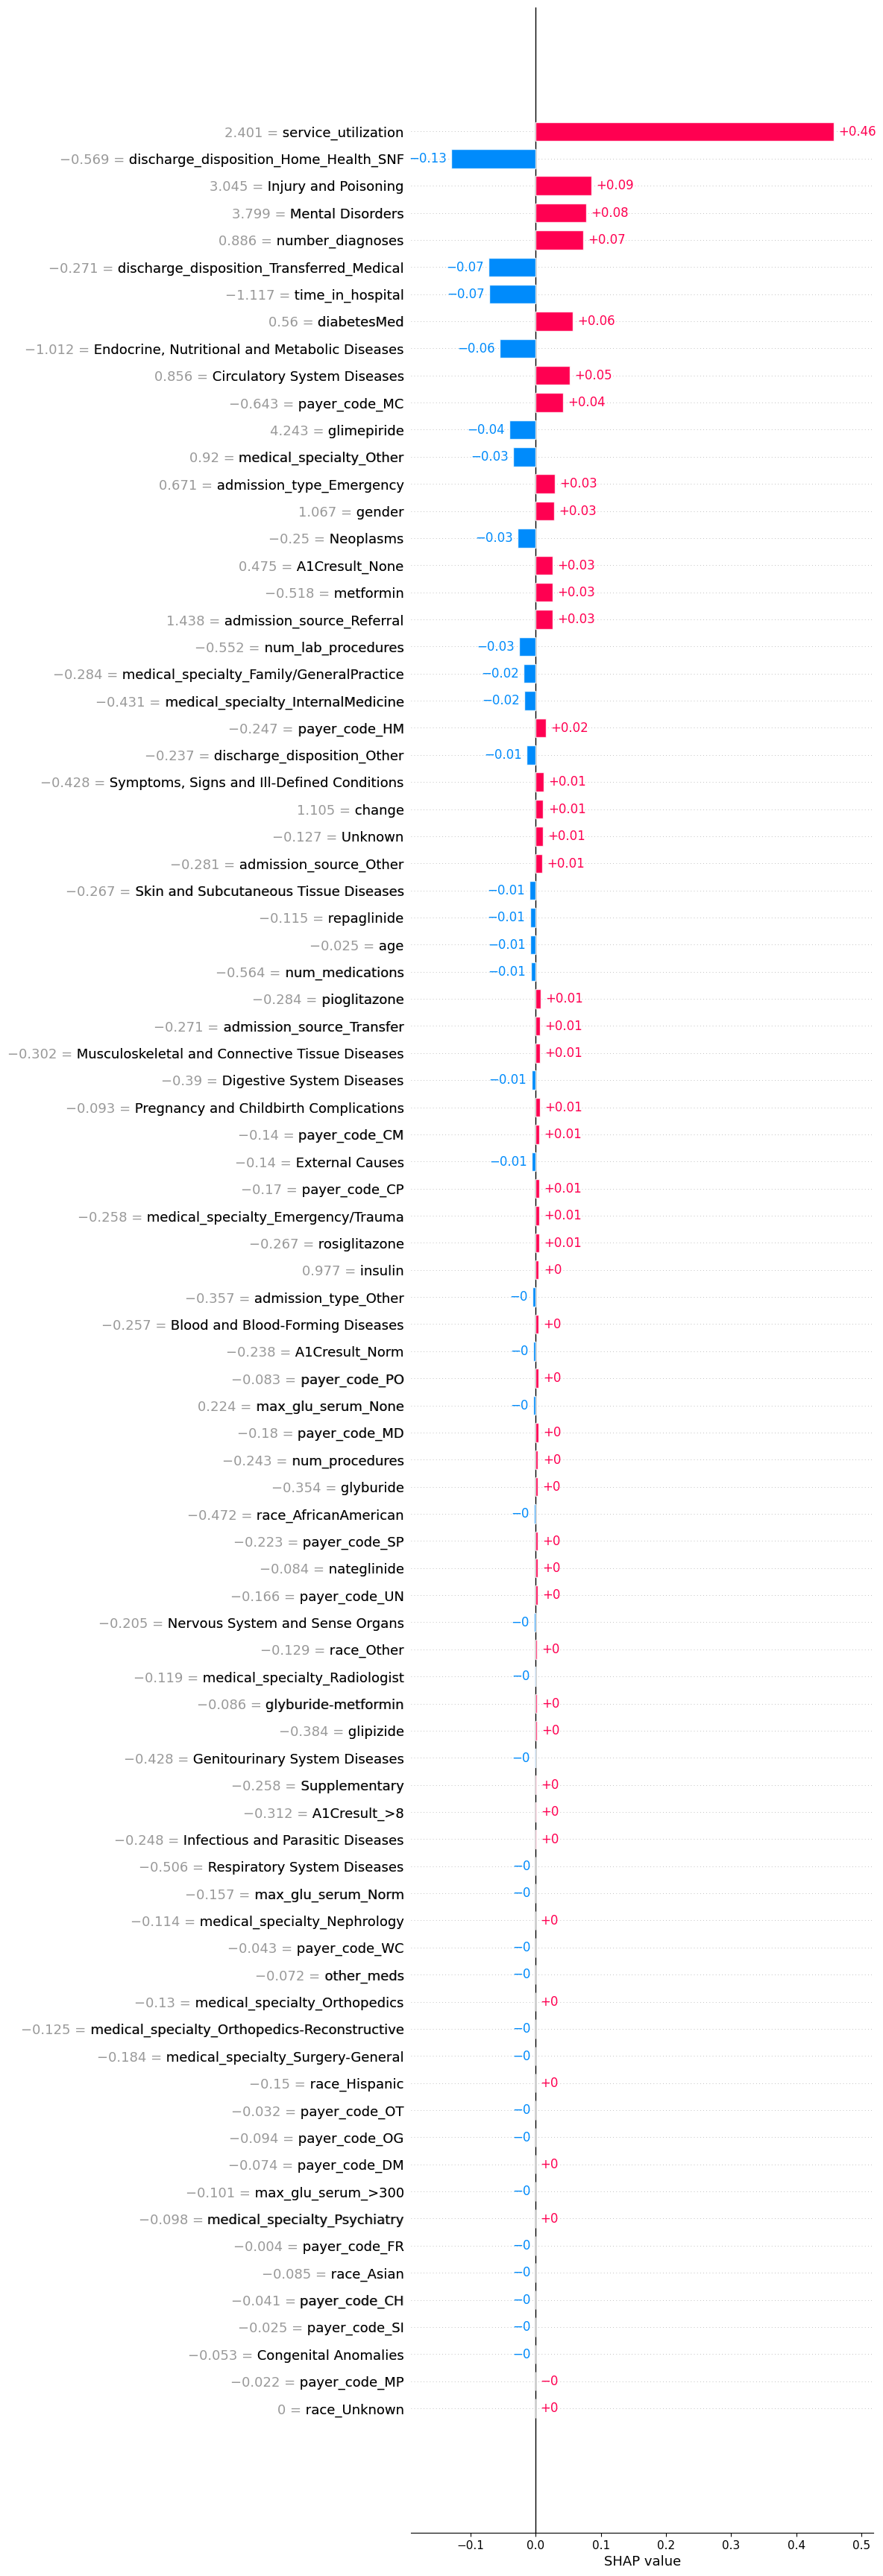

In [40]:
feature_names = X_train.columns
explainer_lr = shap.LinearExplainer(clf_lr, X_train_scaled,feature_names=feature_names)
shap_values_lr = explainer_lr(X_test_scaled)

shap.plots.bar(shap_values_lr[20],max_display=len(X_train.columns))

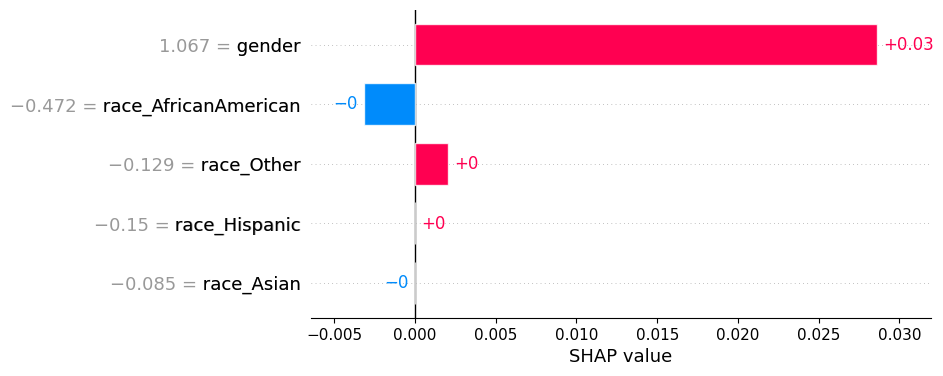

In [41]:
sensitive_shap_values = shap_values_lr[:, sensitive_idx]
shap.plots.bar(
    sensitive_shap_values[20],
    max_display=len(sensitive_features)
)

In [43]:
X_test.iloc[20][[
    "race_Asian",
    "race_AfricanAmerican",
    "race_Hispanic",
    "race_Other"
]]

race_Asian              0
race_AfricanAmerican    0
race_Hispanic           0
race_Other              0
Name: 40809, dtype: int64